In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings('ignore')


## Read training and test datasets


In [2]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df


In [3]:
df_train = read_data('kospi_train.csv')
df_test = read_data('kospi_test.csv')

len(df_train), len(df_test)


(986, 244)

In [4]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train


,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [5]:
# the test dataset has daily KOSPI index in 2023
df_test


,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Predict KOSPI of the next day.
### Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [6]:
print(f"훈련 데이터 크기: {len(df_train)}, 테스트 데이터 크기: {len(df_test)}")


훈련 데이터 크기: 986, 테스트 데이터 크기: 244


In [7]:
# 데이터 확인
print("\n훈련 데이터 샘플:")
print(df_train.head())

# 기술 통계량 확인
print("\n훈련 데이터 통계:")
print(df_train.describe())

# 결측치 확인
print("\n결측치 확인:")
print(df_train.isnull().sum())



훈련 데이터 샘플:
        Date         Open          Low         High        Close  Volume
0 2019-01-02  2050.550049  2004.270020  2053.449951  2010.000000  326400
1 2019-01-03  2011.810059  1991.650024  2014.719971  1993.699951  428000
2 2019-01-04  1992.400024  1984.530029  2011.560059  2010.250000  409000
3 2019-01-07  2034.239990  2030.900024  2048.060059  2037.099976  440200
4 2019-01-08  2038.680054  2023.589966  2042.699951  2025.270020  397800

훈련 데이터 통계:
                                Date         Open          Low         High  \
count                            986   986.000000   986.000000   986.000000   
mean   2020-12-30 22:44:03.407708160  2491.245019  2473.949038  2505.511379   
min              2019-01-02 00:00:00  1474.449951  1439.430054  1516.750000   
25%              2020-01-02 06:00:00  2141.460022  2125.494995  2153.652527   
50%              2020-12-29 12:00:00  2373.609985  2355.854980  2387.719971   
75%              2021-12-27 18:00:00  2935.392456  2910.629944  

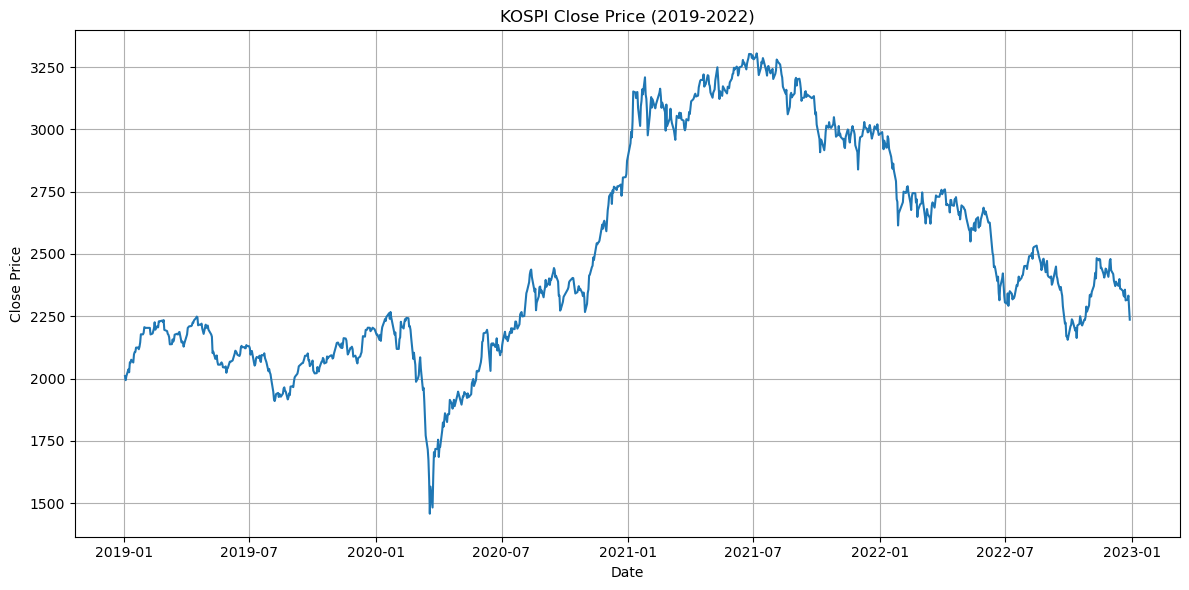

In [8]:
# 데이터 시각화 - 종가 추이
plt.figure(figsize=(12, 6))
plt.plot(df_train['Date'], df_train['Close'])
plt.title('KOSPI Close Price (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.savefig('kospi_close_price.png')
plt.show()


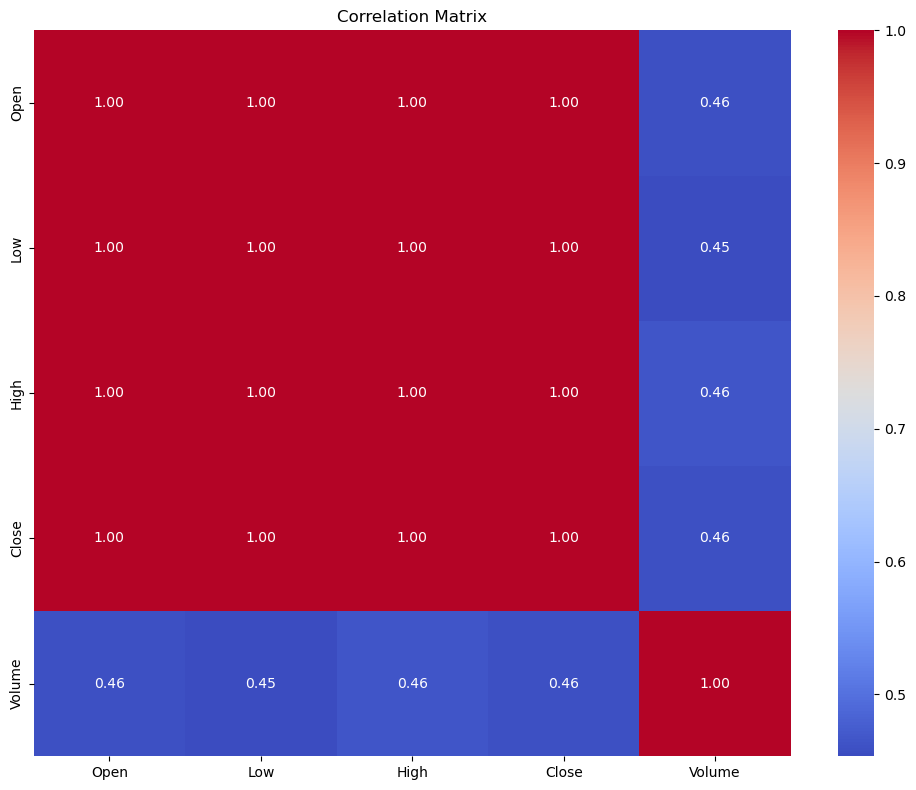

In [9]:
# 상관관계 분석
plt.figure(figsize=(10, 8))
correlation = df_train[['Open', 'Low', 'High', 'Close', 'Volume']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()


In [10]:
# 특성 생성 함수 - Part 1의 경우 이전 날짜의 OHLCV만 사용
def create_features_part1(df):
    """
    다음 날 종가 예측을 위한 특성을 생성합니다.
    Part 1에서는 이전 날짜의 OHLCV만 사용합니다.
    """
    # 다음 날 종가를 타겟으로 설정 (shift(-1)을 사용하여 다음 날 종가를 현재 행으로 가져옴)
    df['Target'] = df['Close'].shift(-1)

    # 기본 특성: 이전 1일, 2일, 3일, 5일의 OHLCV
    lags = [1, 2, 3, 5]
    for lag in lags:
        df[f'Open_lag_{lag}'] = df['Open'].shift(lag)
        df[f'High_lag_{lag}'] = df['High'].shift(lag)
        df[f'Low_lag_{lag}'] = df['Low'].shift(lag)
        df[f'Close_lag_{lag}'] = df['Close'].shift(lag)
        df[f'Volume_lag_{lag}'] = df['Volume'].shift(lag)

    # NaN 값 제거 (시차 변수 계산 초기에 발생하는 NaN)
    df.dropna(inplace=True)

    return df


In [11]:
# 데이터 준비
def prepare_part1_features(train_df, test_df):
    # Part 1 특성 생성
    train_features = create_features_part1(train_df.copy())
    test_features = create_features_part1(test_df.copy())

    # 특성과 타겟 나누기
    # Part 1에서는 이전 날짜의 OHLCV만 사용
    part1_features = [
        'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1',
        'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2',
        'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3',
        'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5'
    ]

    X_train = train_features[part1_features]
    y_train = train_features['Target']

    X_test = test_features[part1_features]
    y_test = test_features['Target']

    return X_train, y_train, X_test, y_test, train_features, test_features


In [12]:
# 스케일링 함수 (Part 1~3 공통)
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


In [13]:
# 모델 평가 함수 (Part 1~3 공통)
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} 성능:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.4f}")

    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}


In [14]:
# 시계열 교차 검증을 위한 함수 (Part 1~3 공통)
def time_series_cv(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')
    return -cv_scores.mean()  # 평균 MSE 반환


In [15]:
# 기본 회귀 모델 세트 (Part 1~2 공통)
def get_base_models():
    return {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1),
        'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
    }


# 모델 훈련 및 예측 함수 (Part 1~2 공통)
def train_and_evaluate_models(X_train, y_train, X_test, y_test):
    models = get_base_models()

    results = {}
    best_model = None
    best_score = float('inf')

    for name, model in models.items():
        print(f"\n{name} 모델 훈련 중...")

        # 시계열 교차 검증
        cv_score = time_series_cv(model, X_train, y_train)
        print(f"교차 검증 MSE: {cv_score:.2f}")

        # 전체 훈련 데이터로 모델 훈련
        model.fit(X_train, y_train)

        # 테스트 데이터로 예측
        y_pred = model.predict(X_test)

        # 모델 평가
        eval_results = evaluate_model(y_test, y_pred, name)
        results[name] = eval_results

        # 최고 성능 모델 저장
        if eval_results['mse'] < best_score:
            best_score = eval_results['mse']
            best_model = (name, model)

    return results, best_model


In [16]:
# Part 1 실행: 기본 모델 훈련 및 평가
print("\n=== Part 1: 이전 날짜의 OHLCV를 사용한 KOSPI 종가 예측 ===")
X_train, y_train, X_test, y_test, train_features, test_features = prepare_part1_features(df_train, df_test)

print("\n사용된 특성:")
print(X_train.columns.tolist())



=== Part 1: 이전 날짜의 OHLCV를 사용한 KOSPI 종가 예측 ===

사용된 특성:
['Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5']


In [17]:
# 스케일링
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)


In [18]:
# 모델 훈련 및 평가
results_part1, (best_model_name, best_model) = train_and_evaluate_models(X_train_scaled, y_train, X_test_scaled, y_test)

# 최고 성능 모델 시각화
print(f"\n최고 성능 모델: {best_model_name}")



Linear Regression 모델 훈련 중...
교차 검증 MSE: 2473.47
Linear Regression 성능:
MSE: 1143.65
RMSE: 33.82
MAE: 26.96
R^2: 0.8274

Ridge Regression 모델 훈련 중...
교차 검증 MSE: 2712.89
Ridge Regression 성능:
MSE: 1116.04
RMSE: 33.41
MAE: 26.51
R^2: 0.8315

Lasso Regression 모델 훈련 중...
교차 검증 MSE: 2474.96
Lasso Regression 성능:
MSE: 1147.20
RMSE: 33.87
MAE: 26.94
R^2: 0.8268

Elastic Net 모델 훈련 중...
교차 검증 MSE: 4028.32
Elastic Net 성능:
MSE: 1436.34
RMSE: 37.90
MAE: 29.50
R^2: 0.7832

Random Forest 모델 훈련 중...


교차 검증 MSE: 29371.72


Random Forest 성능:
MSE: 1478.25
RMSE: 38.45
MAE: 30.68
R^2: 0.7768

Gradient Boosting 모델 훈련 중...


교차 검증 MSE: 27247.08


Gradient Boosting 성능:
MSE: 1321.56
RMSE: 36.35
MAE: 28.78
R^2: 0.8005

XGBoost 모델 훈련 중...


교차 검증 MSE: 28076.87
XGBoost 성능:
MSE: 2247.45
RMSE: 47.41
MAE: 37.34
R^2: 0.6607

최고 성능 모델: Ridge Regression


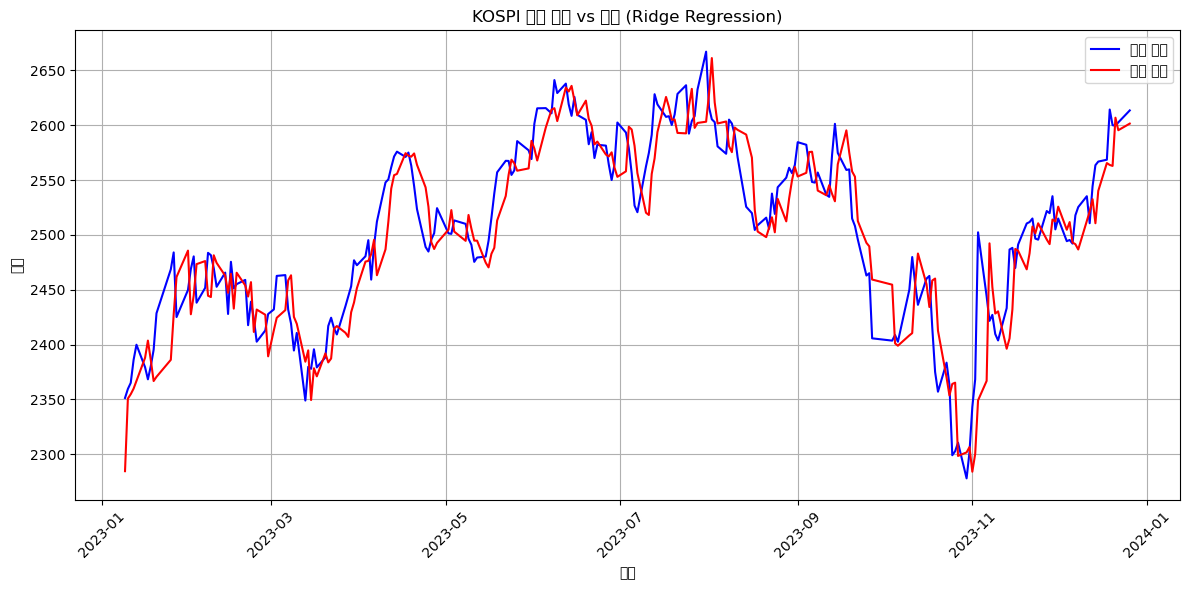

In [19]:
# 예측 결과 시각화
y_pred = best_model.predict(X_test_scaled)

# 마지막 행 제거로 길이 맞추기
dates = test_features['Date'].iloc[:-1]
y_test_aligned = y_test.values[:-1]
y_pred_aligned = y_pred[:-1]

plt.figure(figsize=(12, 6))
plt.plot(dates, y_test_aligned, label='실제 종가', color='blue')
plt.plot(dates, y_pred_aligned, label='예측 종가', color='red')
plt.title(f'KOSPI 종가 예측 vs 실제 ({best_model_name})')
plt.xlabel('날짜')
plt.ylabel('종가')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part1_model_prediction.png')
plt.show()


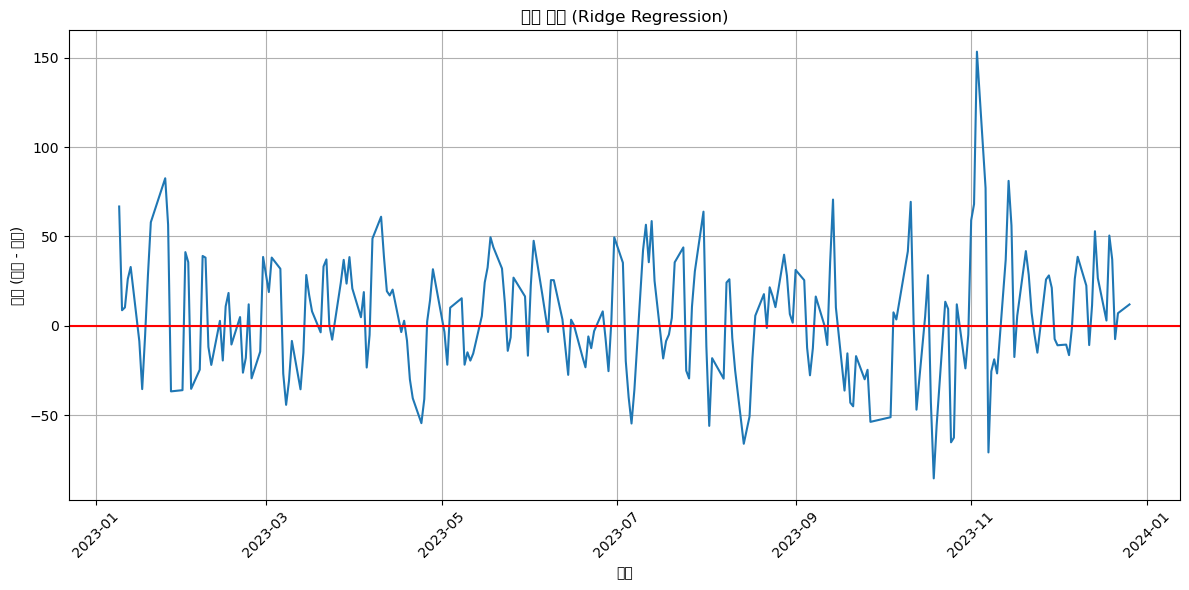

In [20]:
# 예측 오차 시각화
errors = y_test_aligned - y_pred_aligned

plt.figure(figsize=(12, 6))
plt.plot(dates, errors)
plt.axhline(y=0, color='r', linestyle='-')
plt.title(f'예측 오차 ({best_model_name})')
plt.xlabel('날짜')
plt.ylabel('오차 (실제 - 예측)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part1_prediction_errors.png')
plt.show()


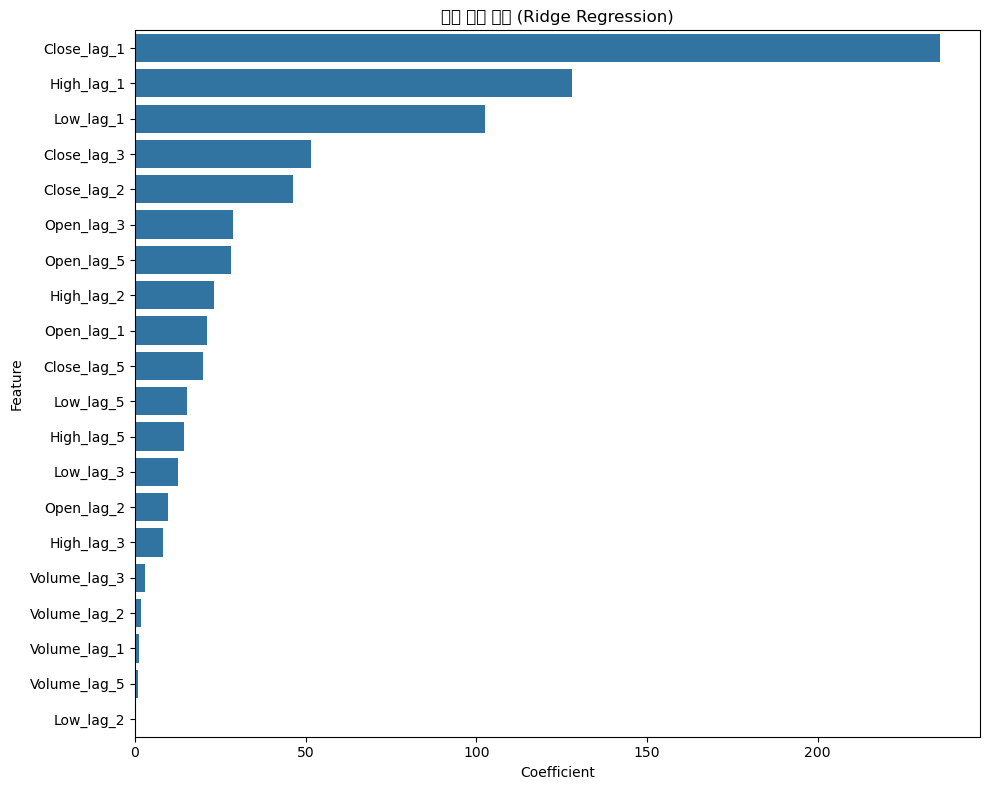


특성 계수:
         Feature  Coefficient
3    Close_lag_1   235.778411
1     High_lag_1   127.940271
2      Low_lag_1   102.524795
13   Close_lag_3    51.489648
8    Close_lag_2    46.298581
10    Open_lag_3    28.631218
15    Open_lag_5    28.195977
6     High_lag_2    23.161581
0     Open_lag_1    20.953941
18   Close_lag_5    19.803004
17     Low_lag_5    15.221526
16    High_lag_5    14.326423
12     Low_lag_3    12.636700
5     Open_lag_2     9.696754
11    High_lag_3     8.275053
14  Volume_lag_3     2.800526
9   Volume_lag_2     1.653486
4   Volume_lag_1     1.246714
19  Volume_lag_5     0.784583
7      Low_lag_2     0.049498


In [21]:
# 모델 계수 또는 특성 중요도 시각화
if hasattr(best_model, 'feature_importances_'):  # 트리 기반 모델
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title(f'특성 중요도 ({best_model_name})')
    plt.tight_layout()
    plt.savefig('part1_feature_importance.png')
    plt.show()

    print("\n특성 중요도:")
    print(feature_importances)

elif hasattr(best_model, 'coef_'):  # 선형 모델
    # 계수의 절댓값을 중요도로 사용
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': np.abs(best_model.coef_)  # 절댓값 사용
    }).sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients)
    plt.title(f'특성 계수 크기 ({best_model_name})')
    plt.tight_layout()
    plt.savefig('part1_feature_coefficients.png')
    plt.show()

    print("\n특성 계수:")
    print(coefficients)


In [22]:
# 모델 저장
joblib.dump(best_model, 'kospi_part1_model.pkl')
joblib.dump(scaler, 'kospi_part1_scaler.pkl')
print(f"\n최고 성능 모델 '{best_model_name}' 저장 완료: 'kospi_part1_model.pkl'")



최고 성능 모델 'Ridge Regression' 저장 완료: 'kospi_part1_model.pkl'


## Part 2. Use more predictors to improve your model.

### Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available.


In [23]:
def create_technical_features(df):
    """
    기술적 분석 지표 생성 함수
    """
    # 이동평균선
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA60'] = df['Close'].rolling(window=60).mean()

    # 일별 변동성
    df['Daily_Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

    # RSI (상대강도지수)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 모멘텀
    df['Momentum'] = df['Close'].pct_change(periods=20)

    # 연속 상승/하락일 수
    df['Consecutive_Up_Days'] = df['Close'].diff().gt(0).rolling(window=10).sum()
    df['Consecutive_Down_Days'] = df['Close'].diff().lt(0).rolling(window=10).sum()

    # 볼린저 밴드
    df['Bollinger_Middle'] = df['Close'].rolling(window=20).mean()
    df['Bollinger_Upper'] = df['Bollinger_Middle'] + 2 * df['Close'].rolling(window=20).std()
    df['Bollinger_Lower'] = df['Bollinger_Middle'] - 2 * df['Close'].rolling(window=20).std()

    return df


In [24]:
PART2_EXTRA_FEATURES = [
    'MA5', 'MA20', 'MA60',
    'Daily_Return', 'Volatility',
    'RSI',
    'Momentum',
    'Consecutive_Up_Days', 'Consecutive_Down_Days',
    'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower'
]

LAG_COLUMNS = ['Open', 'High', 'Low', 'Close', 'Volume']
LAGS = [1, 2, 3, 5]


def add_lag_features(df):
    for lag in LAGS:
        for col in LAG_COLUMNS:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df


def prepare_part2_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m-%d')
    test_df['Date'] = pd.to_datetime(test_df['Date'], format='%Y-%m-%d')

    # 특성 생성
    train_features = create_technical_features(train_df)
    test_features = create_technical_features(test_df)

    train_features = add_lag_features(train_features)
    test_features = add_lag_features(test_features)

    # 다음 날 종가를 타겟으로 설정
    train_features['Target'] = train_features['Close'].shift(-1)
    test_features['Target'] = test_features['Close'].shift(-1)

    part2_features = [f'{col}_lag_{lag}' for lag in LAGS for col in LAG_COLUMNS] + PART2_EXTRA_FEATURES

    # NaN 값 제거
    train_features.dropna(subset=part2_features + ['Target'], inplace=True)
    test_features.dropna(subset=part2_features + ['Target'], inplace=True)

    # 특성과 타겟 분리
    X_train = train_features[part2_features]
    y_train = train_features['Target']
    X_test = test_features[part2_features]
    y_test = test_features['Target']

    return X_train, y_train, X_test, y_test, train_features, test_features


In [25]:
def visualize_prediction_results(test_features, y_test, model, X_test_scaled, model_name, filename):
    y_pred = model.predict(X_test_scaled)

    # 마지막 행 제거로 길이 맞추기
    dates = test_features['Date'].iloc[:-1]
    y_test_aligned = y_test.values[:-1]
    y_pred_aligned = y_pred[:-1]

    plt.figure(figsize=(12, 6))
    plt.plot(dates, y_test_aligned, label='실제 종가', color='blue')
    plt.plot(dates, y_pred_aligned, label='예측 종가', color='red')
    plt.title(f'KOSPI 종가 예측 vs 실제 ({model_name})')
    plt.xlabel('날짜')
    plt.ylabel('종가')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

    return y_test_aligned, y_pred_aligned, dates


def visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, model_name, filename):
    errors = y_test_aligned - y_pred_aligned

    plt.figure(figsize=(12, 6))
    plt.plot(dates, errors)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title(f'예측 오차 ({model_name})')
    plt.xlabel('날짜')
    plt.ylabel('오차 (실제 - 예측)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

    return errors


def visualize_predictions(test_features, y_test, model, X_test_scaled, model_name, pred_filename, error_filename):
    y_test_aligned, y_pred_aligned, dates = visualize_prediction_results(
        test_features, y_test, model, X_test_scaled, model_name, pred_filename
    )
    errors = visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, model_name, error_filename)
    return y_test_aligned, y_pred_aligned, dates, errors


In [26]:
# Part 2 실행: 기술적 지표를 추가한 KOSPI 종가 예측
print("\n=== Part 2: 추가 특성을 활용한 KOSPI 종가 예측 ===")

X_train2, y_train2, X_test2, y_test2, train_features2, test_features2 = prepare_part2_features(df_train, df_test)

print("\n사용된 특성:")
print(X_train2.columns.tolist())

X_train2_scaled, X_test2_scaled, scaler2 = scale_features(X_train2, X_test2)



=== Part 2: 추가 특성을 활용한 KOSPI 종가 예측 ===

사용된 특성:
['Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5', 'MA5', 'MA20', 'MA60', 'Daily_Return', 'Volatility', 'RSI', 'Momentum', 'Consecutive_Up_Days', 'Consecutive_Down_Days', 'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower']



Linear Regression 모델 훈련 중...
교차 검증 MSE: 1822.13
Linear Regression 성능:
MSE: 587.00
RMSE: 24.23
MAE: 18.49
R^2: 0.8971

Ridge Regression 모델 훈련 중...
교차 검증 MSE: 2428.62
Ridge Regression 성능:
MSE: 587.04
RMSE: 24.23
MAE: 18.22
R^2: 0.8970

Lasso Regression 모델 훈련 중...
교차 검증 MSE: 1661.90
Lasso Regression 성능:
MSE: 612.97
RMSE: 24.76
MAE: 18.79
R^2: 0.8925

Elastic Net 모델 훈련 중...
교차 검증 MSE: 3868.43
Elastic Net 성능:
MSE: 803.57
RMSE: 28.35
MAE: 21.90
R^2: 0.8591

Random Forest 모델 훈련 중...


교차 검증 MSE: 52045.02


Random Forest 성능:
MSE: 1653.32
RMSE: 40.66
MAE: 32.38
R^2: 0.7100

Gradient Boosting 모델 훈련 중...


교차 검증 MSE: 51394.49


Gradient Boosting 성능:
MSE: 942.80
RMSE: 30.71
MAE: 24.43
R^2: 0.8347

XGBoost 모델 훈련 중...


교차 검증 MSE: 60940.67
XGBoost 성능:
MSE: 2076.29
RMSE: 45.57
MAE: 36.32
R^2: 0.6359


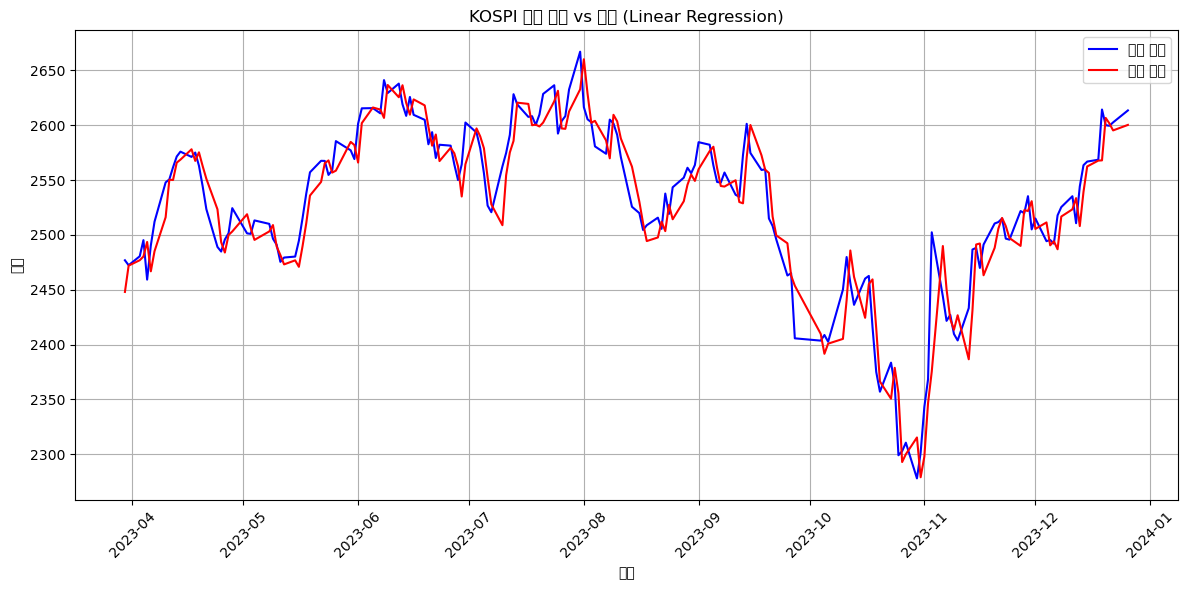

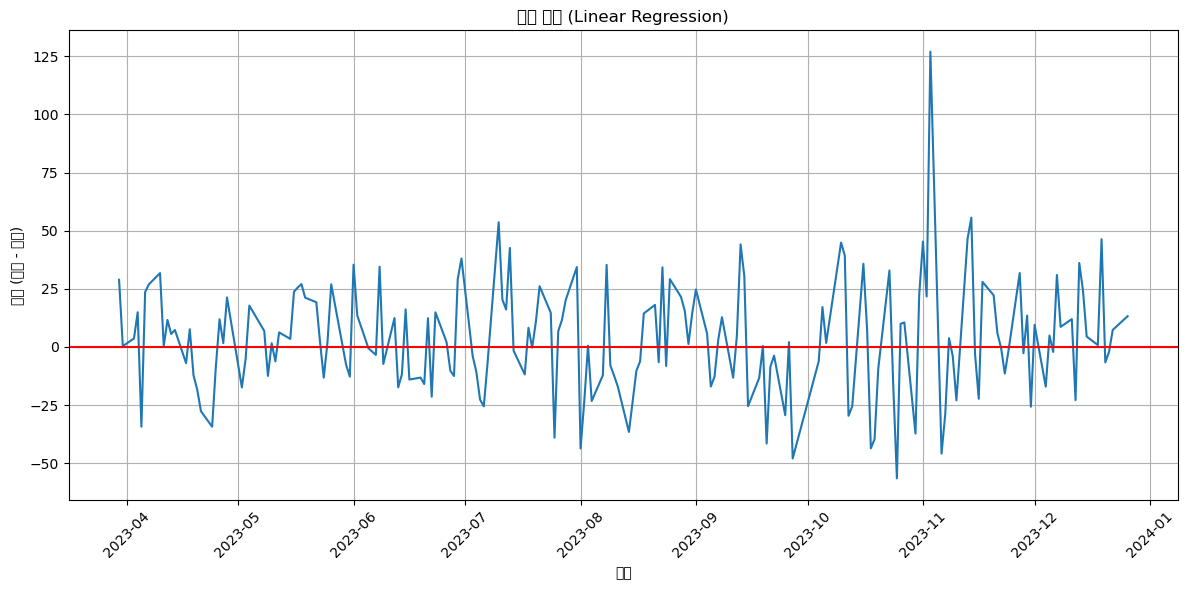


최고 성능 모델 'Linear Regression' 저장 완료: 'kospi_part2_model.pkl'


In [27]:
# 모델 훈련 및 평가
results_part2, best_model2 = train_and_evaluate_models(X_train2_scaled, y_train2, X_test2_scaled, y_test2)
best_model2_name, best_model2_estimator = best_model2

# 시각화
visualize_predictions(
    test_features2, y_test2, best_model2_estimator, X_test2_scaled, best_model2_name,
    'part2_model_prediction.png', 'part2_prediction_errors.png'
)

# 모델 저장
joblib.dump(best_model2_estimator, 'kospi_part2_model.pkl')
joblib.dump(scaler2, 'kospi_part2_scaler.pkl')
print(f"\n최고 성능 모델 '{best_model2_name}' 저장 완료: 'kospi_part2_model.pkl'")


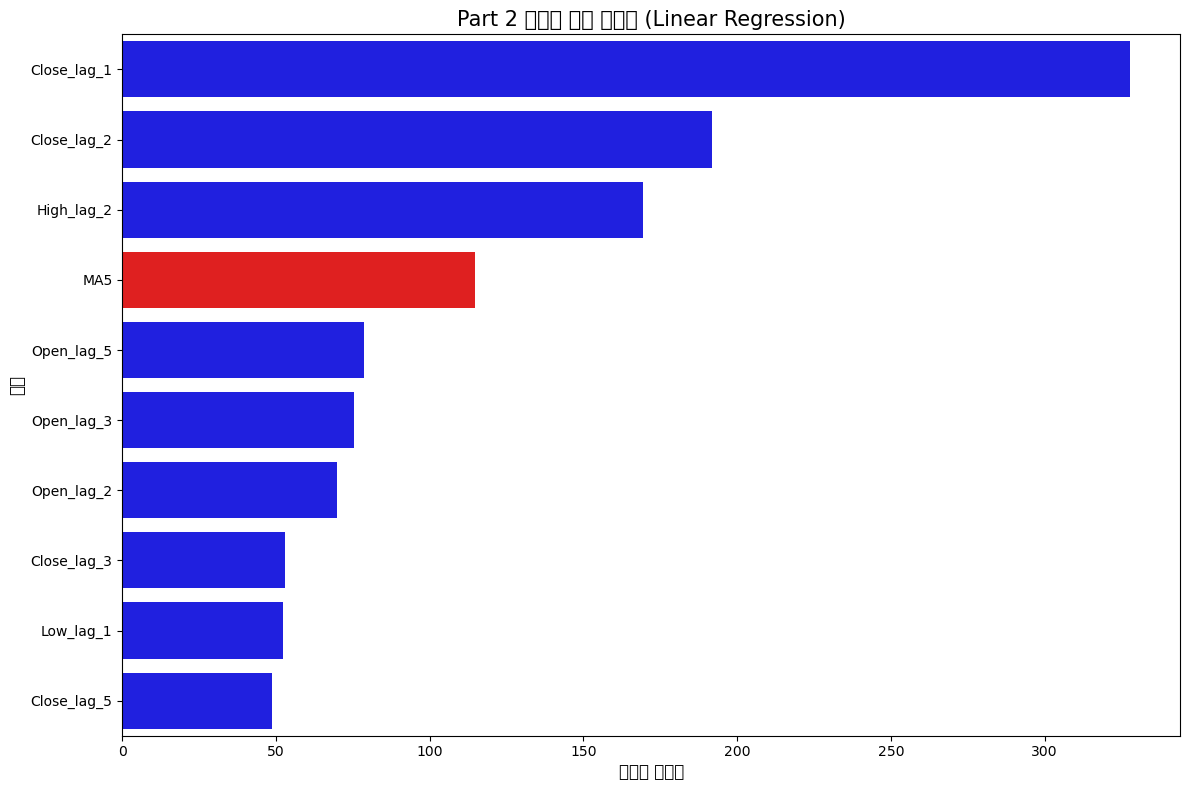


주요 특성 계수:
             Feature  Coefficient
20               MA5   114.659571
25               RSI     1.733509
29  Bollinger_Middle     0.592722


In [28]:
# 특성 중요도 시각화 및 분석
if hasattr(best_model2_estimator, 'coef_'):  # 선형 모델
    coefficients2 = pd.DataFrame({
        'Feature': X_train2.columns,
        'Coefficient': np.abs(best_model2_estimator.coef_)
    }).sort_values('Coefficient', ascending=False)

    top_features2 = coefficients2.head(10)

    plt.figure(figsize=(12, 8))
    plt.title(f'Part 2 모델의 특성 중요도 ({best_model2_name})', fontsize=15)

    highlight_features = ['MA5', 'RSI', 'Bollinger_Middle']
    colors = ['red' if feat in highlight_features else 'blue' for feat in top_features2['Feature']]

    sns.barplot(x='Coefficient', y='Feature', data=top_features2, palette=colors)
    plt.xlabel('계수의 절댓값', fontsize=12)
    plt.ylabel('특성', fontsize=12)
    plt.tight_layout()
    plt.savefig('part2_feature_importance_highlight.png')
    plt.show()

    print("\n주요 특성 계수:")
    print(coefficients2[coefficients2['Feature'].isin(highlight_features)])
elif hasattr(best_model2_estimator, 'feature_importances_'):  # 트리 기반 모델
    feature_importances2 = pd.DataFrame({
        'Feature': X_train2.columns,
        'Importance': best_model2_estimator.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances2)
    plt.title(f'Part 2 모델의 특성 중요도 ({best_model2_name})', fontsize=15)
    plt.tight_layout()
    plt.savefig('part2_feature_importance_highlight.png')
    plt.show()

    print("\n특성 중요도:")
    print(feature_importances2)


## Part 3. Hyperparameter tuning, ensembling, and robustness checks

### Part 2 특성에 요일·MACD·수익률 lag를 더 추가하고, `RandomizedSearchCV`로 각 모델을 튜닝한 뒤 상위 모델을 앙상블합니다.
### 또한 단일 train/test 분할 대신 walk-forward(확장 윈도우) 검증으로 시간에 따른 성능 안정성을 확인하고, 잔차 기반 예측구간을 추가합니다.


In [29]:
def create_extended_features(df):
    """Part 2 기술 지표 + EMA/MACD, 요일 더미, 수익률 lag"""
    df = create_technical_features(df)

    # 지수이동평균 & MACD
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 요일 더미 (월요일 기준, Tue~Fri)
    dow = df['Date'].dt.dayofweek
    for i, name in zip(range(1, 5), ['Tue', 'Wed', 'Thu', 'Fri']):
        df[f'DOW_{name}'] = (dow == i).astype(int)

    # 수익률 lag
    for lag in [1, 2, 3]:
        df[f'Return_lag_{lag}'] = df['Daily_Return'].shift(lag)

    return df


PART3_EXTRA_FEATURES = PART2_EXTRA_FEATURES + [
    'EMA12', 'EMA26', 'MACD', 'MACD_Signal',
    'DOW_Tue', 'DOW_Wed', 'DOW_Thu', 'DOW_Fri',
    'Return_lag_1', 'Return_lag_2', 'Return_lag_3',
]


def prepare_part3_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m-%d')
    test_df['Date'] = pd.to_datetime(test_df['Date'], format='%Y-%m-%d')

    train_features = create_extended_features(train_df)
    test_features = create_extended_features(test_df)

    train_features = add_lag_features(train_features)
    test_features = add_lag_features(test_features)

    train_features['Target'] = train_features['Close'].shift(-1)
    test_features['Target'] = test_features['Close'].shift(-1)

    part3_features = [f'{col}_lag_{lag}' for lag in LAGS for col in LAG_COLUMNS] + PART3_EXTRA_FEATURES

    train_features.dropna(subset=part3_features + ['Target'], inplace=True)
    test_features.dropna(subset=part3_features + ['Target'], inplace=True)

    X_train = train_features[part3_features]
    y_train = train_features['Target']
    X_test = test_features[part3_features]
    y_test = test_features['Target']

    return X_train, y_train, X_test, y_test, train_features, test_features


In [30]:
print("\n=== Part 3: 확장 특성 준비 ===")
X_train3, y_train3, X_test3, y_test3, train_features3, test_features3 = prepare_part3_features(df_train, df_test)

print(f"특성 개수: {len(X_train3.columns)}")
print(X_train3.columns.tolist())

X_train3_scaled, X_test3_scaled, scaler3 = scale_features(X_train3, X_test3)



=== Part 3: 확장 특성 준비 ===
특성 개수: 43
['Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5', 'MA5', 'MA20', 'MA60', 'Daily_Return', 'Volatility', 'RSI', 'Momentum', 'Consecutive_Up_Days', 'Consecutive_Down_Days', 'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower', 'EMA12', 'EMA26', 'MACD', 'MACD_Signal', 'DOW_Tue', 'DOW_Wed', 'DOW_Thu', 'DOW_Fri', 'Return_lag_1', 'Return_lag_2', 'Return_lag_3']


In [31]:
# RandomizedSearchCV로 모델별 하이퍼파라미터 탐색 (TimeSeriesSplit 기준)
param_distributions = {
    'Ridge Regression': (Ridge(), {'alpha': st.loguniform(1e-2, 1e3)}),
    'Lasso Regression': (Lasso(max_iter=20000), {'alpha': st.loguniform(1e-4, 1e1)}),
    'Elastic Net': (ElasticNet(max_iter=20000), {'alpha': st.loguniform(1e-4, 1e1), 'l1_ratio': st.uniform(0.0, 1.0)}),
    'Random Forest': (RandomForestRegressor(random_state=42), {
        'n_estimators': st.randint(100, 400),
        'max_depth': st.randint(3, 15),
        'min_samples_leaf': st.randint(1, 10),
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), {
        'n_estimators': st.randint(100, 400),
        'max_depth': st.randint(2, 6),
        'learning_rate': st.loguniform(1e-2, 3e-1),
    }),
    'XGBoost': (XGBRegressor(random_state=42), {
        'n_estimators': st.randint(100, 400),
        'max_depth': st.randint(2, 8),
        'learning_rate': st.loguniform(1e-2, 3e-1),
        'subsample': st.uniform(0.6, 0.4),
        'colsample_bytree': st.uniform(0.6, 0.4),
    }),
}

tscv3 = TimeSeriesSplit(n_splits=5)
tuned_estimators = {}

for name, (estimator, distributions) in param_distributions.items():
    print(f"\n{name} 튜닝 중...")
    search = RandomizedSearchCV(
        estimator, distributions, n_iter=20, cv=tscv3,
        scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
    )
    search.fit(X_train3_scaled, y_train3)
    tuned_estimators[name] = search.best_estimator_
    print(f"최적 파라미터: {search.best_params_}")
    print(f"교차 검증 MSE: {-search.best_score_:.2f}")



Ridge Regression 튜닝 중...


최적 파라미터: {'alpha': np.float64(0.3320559103751956)}
교차 검증 MSE: 1816.81

Lasso Regression 튜닝 중...


최적 파라미터: {'alpha': np.float64(0.09846738873614563)}
교차 검증 MSE: 1658.60

Elastic Net 튜닝 중...


최적 파라미터: {'alpha': np.float64(0.0033205591037519565), 'l1_ratio': np.float64(0.5247564316322378)}
교차 검증 MSE: 1784.26

Random Forest 튜닝 중...


최적 파라미터: {'max_depth': 14, 'min_samples_leaf': 9, 'n_estimators': 148}
교차 검증 MSE: 49827.81

Gradient Boosting 튜닝 중...


최적 파라미터: {'learning_rate': np.float64(0.044684675025045834), 'max_depth': 4, 'n_estimators': 363}
교차 검증 MSE: 52467.30

XGBoost 튜닝 중...


최적 파라미터: {'colsample_bytree': np.float64(0.602208846849441), 'learning_rate': np.float64(0.1601531217136121), 'max_depth': 2, 'n_estimators': 262, 'subsample': np.float64(0.9160702162124823)}
교차 검증 MSE: 49710.11


In [32]:
# 튜닝된 모델들을 테스트셋에서 평가
tuned_results = {}
for name, model in tuned_estimators.items():
    y_pred = model.predict(X_test3_scaled)
    tuned_results[name] = evaluate_model(y_test3, y_pred, f"{name} (Tuned)")

best_tuned_name = min(tuned_results, key=lambda n: tuned_results[n]['mse'])
print(f"\nPart 3 튜닝 모델 중 최고 성능: {best_tuned_name}")


Ridge Regression (Tuned) 성능:
MSE: 598.41
RMSE: 24.46
MAE: 18.54
R^2: 0.8951
Lasso Regression (Tuned) 성능:
MSE: 590.31
RMSE: 24.30
MAE: 18.39
R^2: 0.8965
Elastic Net (Tuned) 성능:
MSE: 599.32
RMSE: 24.48
MAE: 18.48
R^2: 0.8949
Random Forest (Tuned) 성능:
MSE: 1106.90
RMSE: 33.27
MAE: 26.07
R^2: 0.8059
Gradient Boosting (Tuned) 성능:
MSE: 952.23
RMSE: 30.86
MAE: 24.42
R^2: 0.8330
XGBoost (Tuned) 성능:
MSE: 1448.35
RMSE: 38.06
MAE: 31.18
R^2: 0.7460

Part 3 튜닝 모델 중 최고 성능: Lasso Regression


In [33]:
# 상위 3개 튜닝 모델로 VotingRegressor 앙상블 구성
top3_names = sorted(tuned_results, key=lambda n: tuned_results[n]['mse'])[:3]
print(f"앙상블에 사용할 모델: {top3_names}")

voting_ensemble = VotingRegressor(
    estimators=[(name, clone(tuned_estimators[name])) for name in top3_names]
)
voting_ensemble.fit(X_train3_scaled, y_train3)
y_pred_voting = voting_ensemble.predict(X_test3_scaled)
voting_result = evaluate_model(y_test3, y_pred_voting, 'Voting Ensemble')

tuned_results['Voting Ensemble'] = voting_result
tuned_estimators['Voting Ensemble'] = voting_ensemble

best_part3_name = min(tuned_results, key=lambda n: tuned_results[n]['mse'])
best_part3_model = tuned_estimators[best_part3_name]
print(f"\nPart 3 최종 최고 성능 모델: {best_part3_name}")


앙상블에 사용할 모델: ['Lasso Regression', 'Ridge Regression', 'Elastic Net']


Voting Ensemble 성능:
MSE: 595.27
RMSE: 24.40
MAE: 18.47
R^2: 0.8956

Part 3 최종 최고 성능 모델: Lasso Regression


In [34]:
# 나이브 베이스라인: 다음날 종가 = 오늘 종가 (persistence baseline)
# 종가 '레벨' 예측은 하루 사이 랜덤워크에 가까워, 아무 모델 없이 오늘 종가를
# 그대로 복사하는 것만으로도 R2가 매우 높게 나올 수 있다. 우리 모델이 실제로
# 이 단순 베이스라인보다 나은지 확인한다 (Part 3와 동일한 평가 대상 행 사용).
naive_pred = test_features3['Close'].values
naive_true = test_features3['Target'].values
naive_result = evaluate_model(naive_true, naive_pred, 'Naive Persistence (Close_t -> Close_t+1)')


Naive Persistence (Close_t -> Close_t+1) 성능:
MSE: 569.34
RMSE: 23.86
MAE: 17.64
R^2: 0.9002


       Part              Model          mse       rmse        mae        r2
0  Baseline  Naive Persistence   569.342140  23.860891  17.640866  0.900151
1    Part 1   Ridge Regression  1116.044930  33.407259  26.511927  0.831524
2    Part 2  Linear Regression   587.003436  24.228154  18.488249  0.897054
3    Part 3   Ridge Regression   598.414075  24.462503  18.542672  0.895053
4    Part 3   Lasso Regression   590.305496  24.296203  18.390599  0.896475
5    Part 3        Elastic Net   599.320976  24.481033  18.484412  0.894894
6    Part 3      Random Forest  1106.901146  33.270124  26.069852  0.805877
7    Part 3  Gradient Boosting   952.227645  30.858186  24.421815  0.833003
8    Part 3            XGBoost  1448.353737  38.057243  31.175375  0.745995
9    Part 3    Voting Ensemble   595.272647  24.398210  18.471412  0.895604

나이브 베이스라인(RMSE=23.86)보다 나은 모델 수: 0 / 9


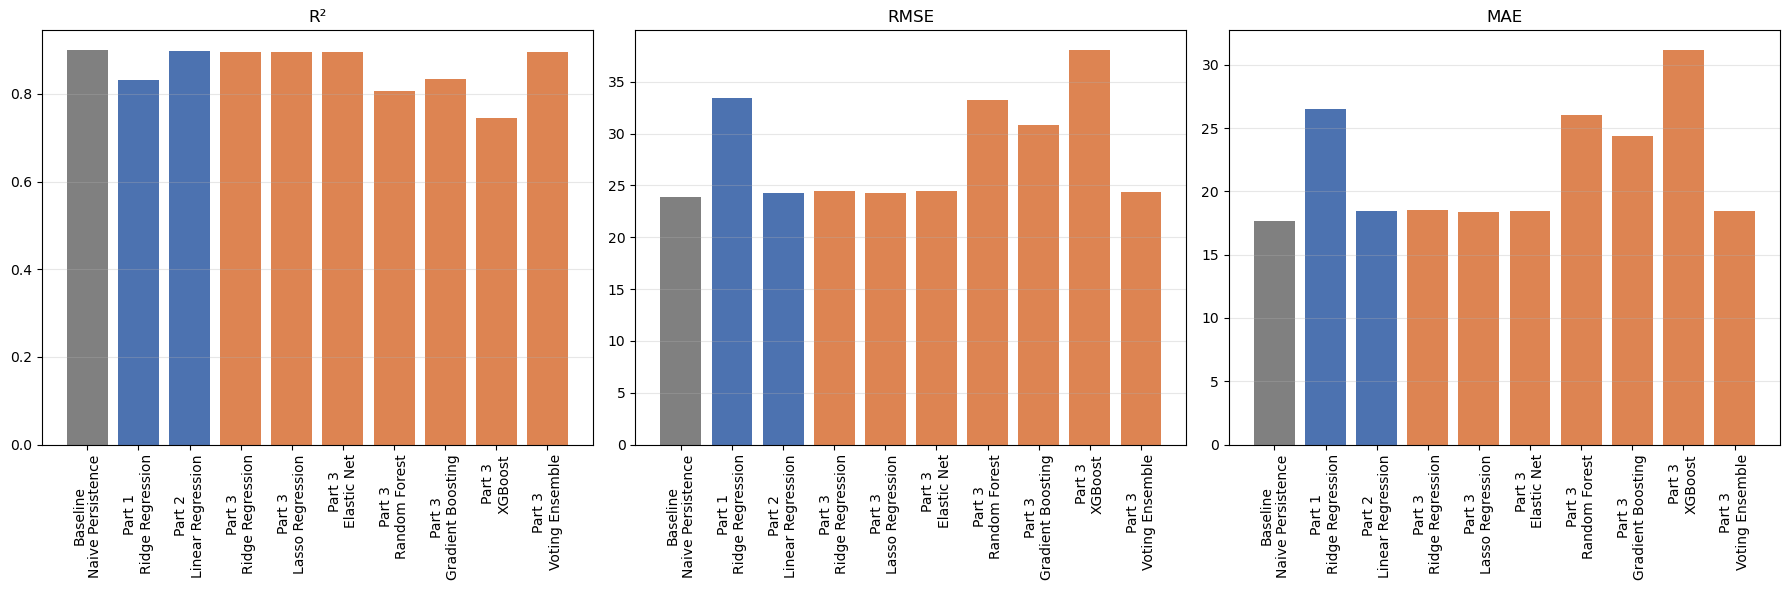

In [35]:
# Baseline / Part 1 / Part 2 / Part 3 성능 비교
comparison_rows = []
comparison_rows.append({'Part': 'Baseline', 'Model': 'Naive Persistence', **naive_result})
comparison_rows.append({'Part': 'Part 1', 'Model': best_model_name, **results_part1[best_model_name]})
comparison_rows.append({'Part': 'Part 2', 'Model': best_model2_name, **results_part2[best_model2_name]})
for name, res in tuned_results.items():
    comparison_rows.append({'Part': 'Part 3', 'Model': name, **res})

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

n_beating_baseline = (comparison_df.loc[comparison_df['Part'] != 'Baseline', 'rmse'] < naive_result['rmse']).sum()
print(f"\n나이브 베이스라인(RMSE={naive_result['rmse']:.2f})보다 나은 모델 수: {n_beating_baseline} / {len(comparison_df) - 1}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = comparison_df['Part'] + '\n' + comparison_df['Model']
part_colors = {'Baseline': '#808080', 'Part 1': '#4C72B0', 'Part 2': '#4C72B0', 'Part 3': '#DD8452'}
colors = [part_colors[part] for part in comparison_df['Part']]
for ax, metric, title in zip(axes, ['r2', 'rmse', 'mae'], ['R²', 'RMSE', 'MAE']):
    ax.bar(labels, comparison_df[metric], color=colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('part3_model_comparison.png')
plt.show()


In [36]:
def walk_forward_validate(model, X_train, y_train, X_test, y_test, step=21):
    """확장 윈도우 방식으로 step 크기만큼 예측 후 실제값을 히스토리에 포함시켜 재학습"""
    X_hist = np.asarray(X_train)
    y_hist = np.asarray(y_train)
    X_test = np.asarray(X_test)
    y_test_arr = np.asarray(y_test)

    n_test = len(X_test)
    preds = np.zeros(n_test)

    for start in range(0, n_test, step):
        end = min(start + step, n_test)
        step_model = clone(model)
        step_model.fit(X_hist, y_hist)
        preds[start:end] = step_model.predict(X_test[start:end])

        X_hist = np.vstack([X_hist, X_test[start:end]])
        y_hist = np.concatenate([y_hist, y_test_arr[start:end]])

    return preds


print("\n=== Walk-forward validation (확장 윈도우, 최종 Part 3 모델 기준) ===")
walk_forward_model = clone(best_part3_model.estimators[0][1]) if best_part3_name == 'Voting Ensemble' else clone(best_part3_model)
y_pred_wf = walk_forward_validate(walk_forward_model, X_train3_scaled, y_train3, X_test3_scaled, y_test3, step=21)

wf_result = evaluate_model(y_test3, y_pred_wf, f'{best_part3_name} (Walk-forward)')



=== Walk-forward validation (확장 윈도우, 최종 Part 3 모델 기준) ===


Lasso Regression (Walk-forward) 성능:
MSE: 585.05
RMSE: 24.19
MAE: 18.30
R^2: 0.8974


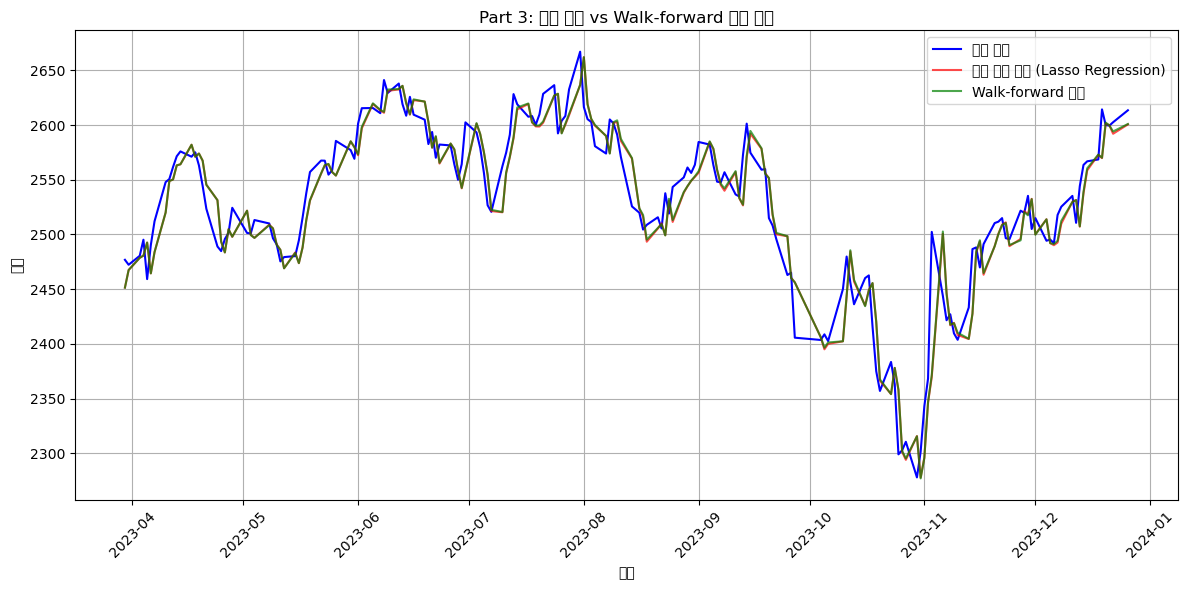

In [37]:
# Walk-forward 예측 vs 단일 학습 예측 비교 시각화
dates3 = test_features3['Date'].iloc[:-1]
y_test3_aligned = y_test3.values[:-1]
y_pred_wf_aligned = y_pred_wf[:-1]
y_pred_single_aligned = best_part3_model.predict(X_test3_scaled)[:-1]

plt.figure(figsize=(12, 6))
plt.plot(dates3, y_test3_aligned, label='실제 종가', color='blue')
plt.plot(dates3, y_pred_single_aligned, label=f'단일 학습 예측 ({best_part3_name})', color='red', alpha=0.7)
plt.plot(dates3, y_pred_wf_aligned, label='Walk-forward 예측', color='green', alpha=0.7)
plt.title('Part 3: 단일 학습 vs Walk-forward 예측 비교')
plt.xlabel('날짜')
plt.ylabel('종가')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part3_walk_forward_prediction.png')
plt.show()


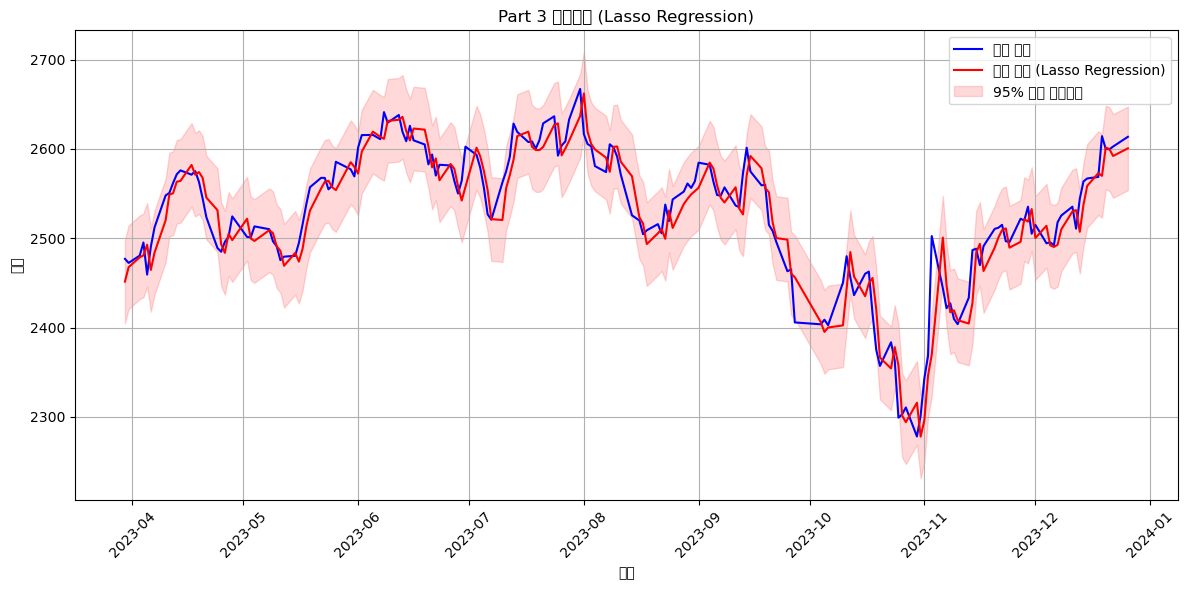

95% 예측구간 실제 커버리지: 96.17%


In [38]:
# 잔차 기반 근사 예측구간 (±1.96 * 잔차 표준편차) 및 잔차 진단
residuals = y_test3_aligned - y_pred_single_aligned
residual_std = residuals.std()
lower = y_pred_single_aligned - 1.96 * residual_std
upper = y_pred_single_aligned + 1.96 * residual_std

plt.figure(figsize=(12, 6))
plt.plot(dates3, y_test3_aligned, label='실제 종가', color='blue')
plt.plot(dates3, y_pred_single_aligned, label=f'예측 종가 ({best_part3_name})', color='red')
plt.fill_between(dates3, lower, upper, color='red', alpha=0.15, label='95% 근사 예측구간')
plt.title(f'Part 3 예측구간 ({best_part3_name})')
plt.xlabel('날짜')
plt.ylabel('종가')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part3_prediction_interval.png')
plt.show()

coverage = np.mean((y_test3_aligned >= lower) & (y_test3_aligned <= upper))
print(f"95% 예측구간 실제 커버리지: {coverage:.2%}")


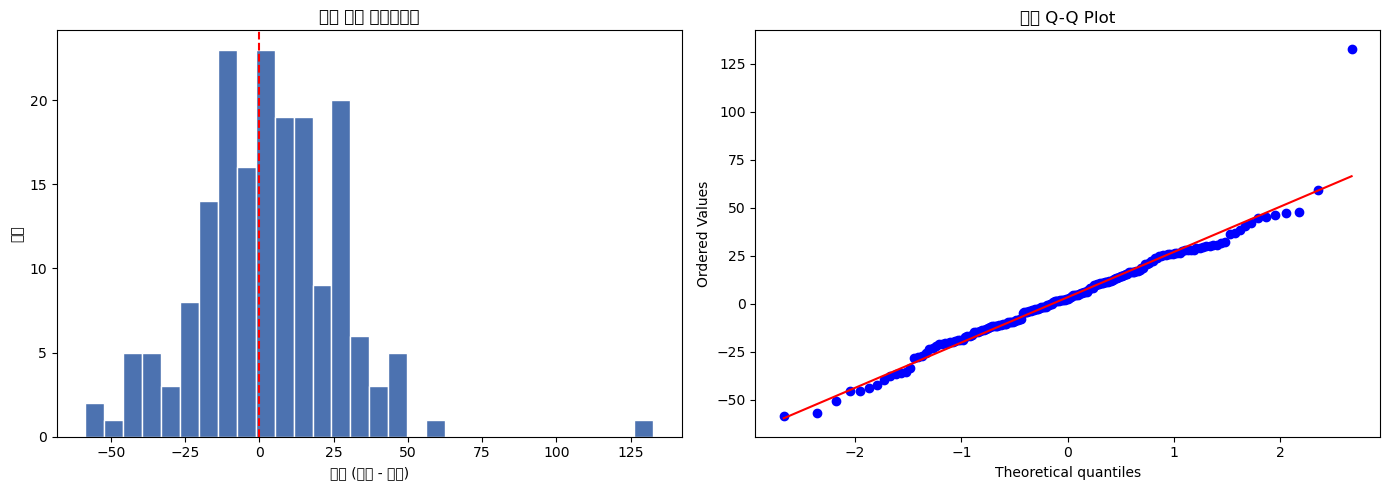

In [39]:
# 잔차 분포 진단: 히스토그램 + Q-Q plot
from scipy import stats as sps

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('잔차 분포 히스토그램')
axes[0].set_xlabel('잔차 (실제 - 예측)')
axes[0].set_ylabel('빈도')

sps.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('잔차 Q-Q Plot')

plt.tight_layout()
plt.savefig('part3_residual_diagnostics.png')
plt.show()


In [40]:
# Part 3 최종 모델 저장
joblib.dump(best_part3_model, 'kospi_part3_model.pkl')
joblib.dump(scaler3, 'kospi_part3_scaler.pkl')
print(f"\n최고 성능 모델 '{best_part3_name}' 저장 완료: 'kospi_part3_model.pkl'")

print("\n=== 최종 요약 ===")
print(comparison_df.sort_values('r2', ascending=False).to_string(index=False))



최고 성능 모델 'Lasso Regression' 저장 완료: 'kospi_part3_model.pkl'

=== 최종 요약 ===
    Part             Model         mse      rmse       mae       r2
Baseline Naive Persistence  569.342140 23.860891 17.640866 0.900151
  Part 2 Linear Regression  587.003436 24.228154 18.488249 0.897054
  Part 3  Lasso Regression  590.305496 24.296203 18.390599 0.896475
  Part 3   Voting Ensemble  595.272647 24.398210 18.471412 0.895604
  Part 3  Ridge Regression  598.414075 24.462503 18.542672 0.895053
  Part 3       Elastic Net  599.320976 24.481033 18.484412 0.894894
  Part 3 Gradient Boosting  952.227645 30.858186 24.421815 0.833003
  Part 1  Ridge Regression 1116.044930 33.407259 26.511927 0.831524
  Part 3     Random Forest 1106.901146 33.270124 26.069852 0.805877
  Part 3           XGBoost 1448.353737 38.057243 31.175375 0.745995
